# 3. mRNA display: PADI4 selection

This notebook shows another example of using clibas to analyze mRNA display library selections with data from Walport and colleagues.
Primarily, this example aims to demonstrate i) the use of `C.pipeline.stream` method to process large datasets sequentially, and ii)  potential pitfalls associated with excessive read filtering. 

For further details and the source of data, see [I. Mathiesen et al. Discovering covalent cyclic peptide inhibitors of peptidyl arginine deiminase 4 (PADI4) using mRNA-display with a genetically encoded electrophilic warhead. Commun. Chem. 2024, 7, 304](https://www.nature.com/articles/s42004-024-01388-9)

In the paper, the authors design and screen mRNA display libraries of cyclic peptides containing non-standard N-δ-Fluoroacetimidoyl ornithine residues. These non-standard amino acids can covalently immobilize to the active site cysteine in PADI enzymes by mimicking substrate arginine side-chains. Additionally, the cyclization is achieved with the use of N-chloroacetylated amino acids utilized for translation initiation. The electrophilic chloroacetyl moeity spontaneously cyclizes with a downstream cysteine residue to yield thioether-closed macrocyclic structures. Currently, this is one of the most common cyclization strategies employed in mRNA display selections. 

The authors released NGS data for three selection campaigns conducted against PADI4: selection with a 15 min incubation time, a 60-min selection, and a control selection against a catalytically inactive mutant of PADI4 (C645A). The NGS-derived DNA reads look something like this:

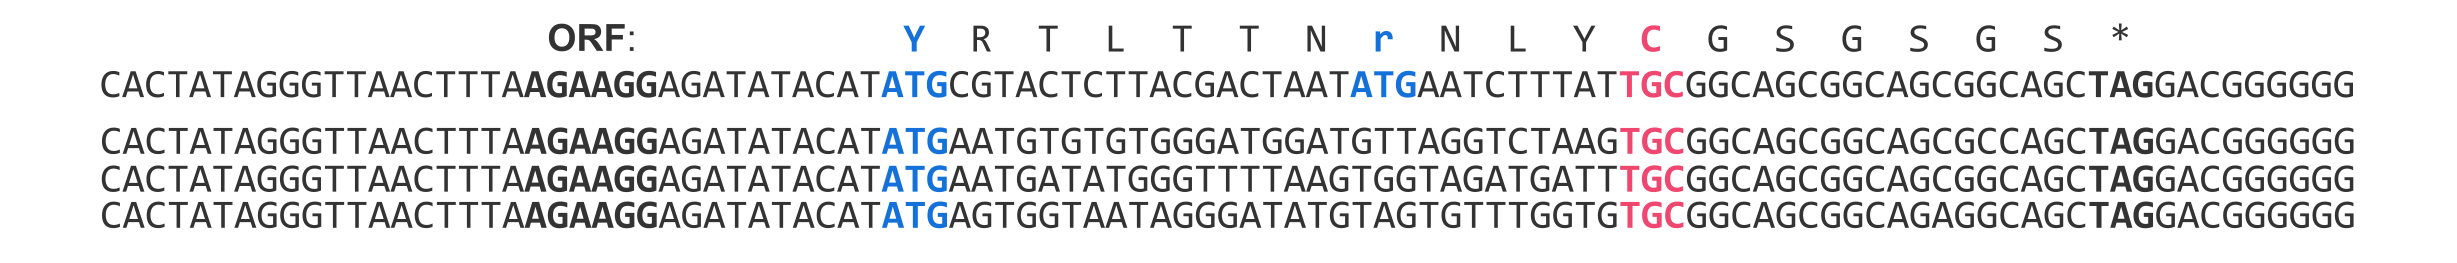

The reads, provided in single-end fixed-length format, cover the entire ORF and start with a defined constant 5' sequence. This makes their parsing relatively easy. The peptide library design features an N-terminal Cl-Ac-L-Tyr (non-canonical translation initiation), followed by a random region of variable legnth  encoded by an (NNK)<sub>x</sub> (x=6-10) insert. The C-terminal sequence contains a cysteine residue used for cyclization, and "GSGSGS" as a linker. These designs are similar to those from example 2 (`2. mRNA display: CCL22 selection`), and can be formalized for clibas pipelines like this:

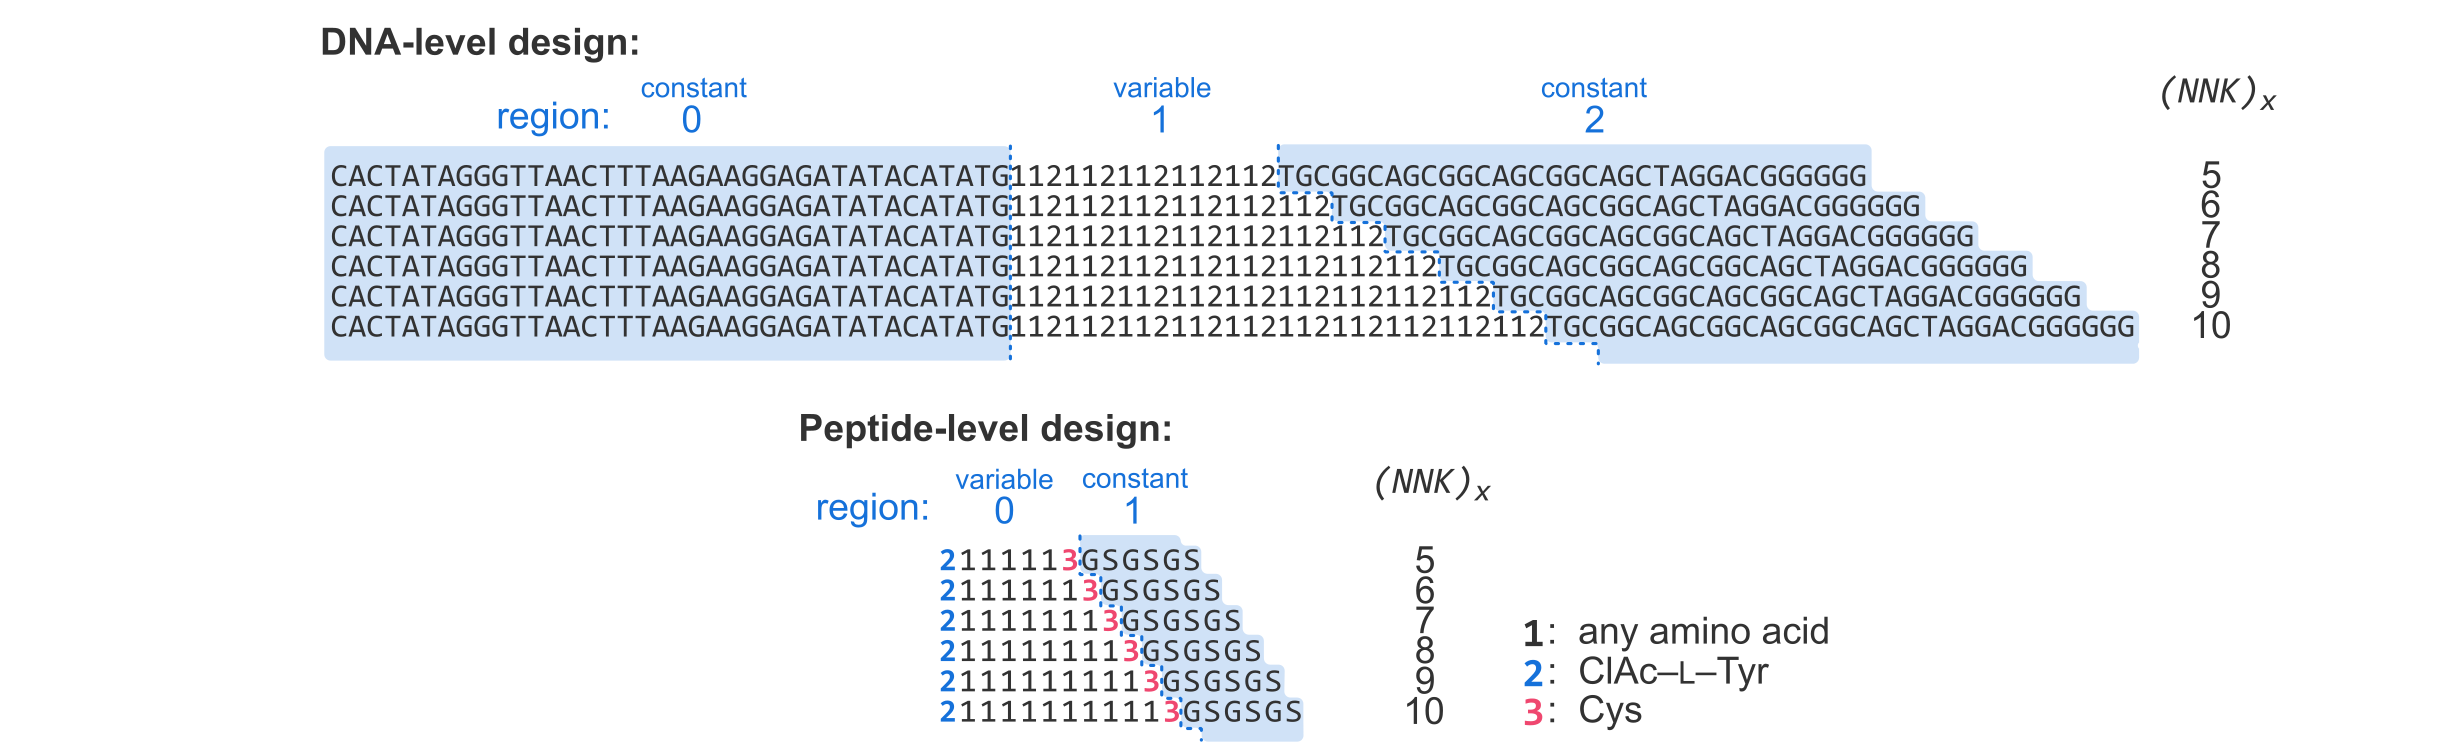

As with example 2, there are other ways to initialize these library designs. For example, the N-terminal Cl-Ac-L-Tyr could be broken into a separate constant region of length 1, and the cysteine could instead be specified as part of the C-terminal constant region. In other words, peptide templates can also be specified like this: `Y111111CGSGSGS`. It is a matter of preference. Specifying the desigs as `21111113GSGSGS` allows us to later call `C.fastq_parser.vr_filter(where='pep', loc=[0], sets=[1, 2, 3])` to ensure that all peptide sequences lacking the C-terminal cysteine are discarded. 

To write a `.yaml` config file for these libraries, we also need to specify a custom translation table where the `ATG` elongation codon encodes N-δ-fluoroacetimidoyl ornithine (denoted as `r` in this example), and provide the `custom_ini_aa` to account for the non-standard translation initiator amino acid. In this example, we will run UMAP/HDBSCAN analysis without providing `aa_SMILES` in the config. This can still be done – peptides will be represented using one-hot encodings.

In addition, we specify `orf_locator`: `"AGGAGA.....ATG"`. This helps the parser locate the ORF at the 5' end of the reads. This is optional. If not specified, `"ATG"` will be used to locate ORFs which works fine most of the time. `TrackerConfig` and `LoggerConfig` specifications are also optional:

```yaml
# yaml config file reproduced here for completeness: 

experiment: "Walport_PADI4_covalent_selection"

constants:
  description: |
    Star symbol (*) is internally reserved for stop codons that terminate
    translation.
    
    Plus and underscore symbols (+ and _) are internally reserved tokens.
    Numerals (1234567890) are internally reserved for library design 
    specifications. These symbols (123456790+_) should not be used to
    encode amino acids.
    
    Other symbols are OK.   
    
  translation_table:
    ATA: "I"
    ATC: "I"
    ATT: "I"
    ATG: "r"
    ACA: "T"
    ACC: "T"
    ACG: "T"
    ACT: "T"
    AAC: "N"
    AAT: "N"
    AAA: "K" 
    AAG: "K"
    AGC: "S"
    AGT: "S"
    AGA: "R"
    AGG: "R"
    CTA: "L" 
    CTC: "L"
    CTG: "L"
    CTT: "L"
    CCA: "P" 
    CCC: "P" 
    CCG: "P" 
    CCT: "P"
    CAC: "H"
    CAT: "H" 
    CAA: "Q" 
    CAG: "Q"
    CGA: "R"
    CGC: "R"
    CGG: "R"
    CGT: "R"
    GTA: "V" 
    GTC: "V" 
    GTG: "V"
    GTT: "V"
    GCA: "A" 
    GCC: "A" 
    GCG: "A" 
    GCT: "A"
    GAC: "D" 
    GAT: "D"
    GAA: "E" 
    GAG: "E"
    GGA: "G" 
    GGC: "G"
    GGG: "G"
    GGT: "G"
    TCA: "S" 
    TCC: "S" 
    TCG: "S"
    TCT: "S"
    TTC: "F" 
    TTT: "F" 
    TTA: "L" 
    TTG: "L"
    TAC: "Y" 
    TAT: "Y" 
    TAA: "*" 
    TAG: "*"
    TGC: "C"
    TGT: "C" 
    TGA: "*" 
    TGG: "W"

  custom_ini_aa: "Y"     
    
LibraryDesigns:
  dna_templates:
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    - "CACTATAGGGTTAACTTTAAGAAGGAGATATACATATG112112112112112112112112112112TGCGGCAGCGGCAGCGGCAGCTAGGACGGGGGG"
    
  dna_monomers:
    1: ["A", "G", "T", "C"] #N
    2: ["G", "T"] #K
    
  pep_templates:
    - "2111113GSGSGS"
    - "21111113GSGSGS"
    - "211111113GSGSGS"
    - "2111111113GSGSGS"
    - "21111111113GSGSGS"
    - "211111111113GSGSGS"
 
  pep_monomers:
    1: ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "r", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    2: ["Y"]
    3: ["C"]

FastqParserConfig:
  orf_locator: "AGGAGA.......ATG"      # A regex pattern that has to match to initiate the ORF 

TrackerConfig:
  logs: "./outputs/Walport_PADI4/60 min"                 # Directory for writing logs to
  parser_out: "./outputs/Walport_PADI4/60 min"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Walport_PADI4/60 min"         # Directory that stores outputs of data analysis operations
  
LoggerConfig:
  verbose: true                     # Verbose loggers print to the console
  log_to_file: false                # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"

```  

In [1]:
import clibas as C

C.initialize(config_path="Walport_PADI4_config.yaml")

[WARNING]: <Dispatcher>: config is missing some basic definitions (bases, amino acids, translation tables, etc); will use defaults for the missing values. . . 
[INFO]: <clibas> succesfully loaded config and is ready. . .


In [2]:
C.pipeline.enque(
    [
        # in this case, DNA reads don't need any prep (trimming, revcom)
        # and can be translated to peptides right away
        # config specifies the "orf_locator" sequence that initiates translation
        C.fastq_parser.translate(stop_readthrough=False),
        # length analysis of trimmed DNA reads and the resulting peptides
        # we do it before filtering any reads to get an unbiased view
        C.analysis_tools.length_analysis(where="pep"),
        C.analysis_tools.length_analysis(where="dna"),
        # analyze average Phred quality scores
        # we do it before filtering any reads to get an unbiased view
        C.analysis_tools.q_score_analysis(loc=None),
        # count the peptides before doing any filtrtion
        C.fastq_parser.count_summary(where="pep", top_n=1000, fmt="csv"),
        # discard the peptides of incorrect length (incompatible with library designs)
        C.fastq_parser.len_filter(where="pep"),
        # discard the peptides with incorrect/overly mutated constant regions
        # up to 3 mutations are tolerated
        C.fastq_parser.cr_filter(where="pep", loc=[1], tol=3),
        # discard the peptides contained unallowed monomers in the variable region
        C.fastq_parser.vr_filter(where="pep", loc=[0], sets=[1, 2, 3]),
        # discard the peptides containing Q scores below 30 in region 0 (random insert region)
        C.fastq_parser.q_score_filt(minQ=30, loc=[0]),
        # clip peptide sequences to region 0 (random insert region)
        C.fastq_parser.fetch_at(where="pep", loc=[0]),
        # discard all peptides containing any ambiguous amino acids
        # stemming from N nucleotide base calling etc
        C.fastq_parser.filt_ambiguous(where="pep"),
        # analyze the convergence of the peptide library at the sequence level
        C.analysis_tools.sequence_convergence_analysis(where="pep"),
        # analyze the convergence of the peptide/DNA library at the token level
        # by token, we mean amino acid/nucleotide: basically positional freq analysis
        C.analysis_tools.token_convergence_analysis(where="pep", loc=None),
        C.analysis_tools.token_convergence_analysis(where="dna", loc=None),
        # unpad all arrays: optional, maybe used to free up some memory; not needed in this case
        C.fastq_parser.unpad(),
        # save the peptide datasets as numpy .npy files - if any downstream analysis in python is envisioned
        C.fastq_parser.save(where="pep", fmt="npy"),
        # count peptides/DNA again - this time after all filtration ops have been called
        C.fastq_parser.count_summary(where="pep", top_n=1000, fmt="csv"),
        C.fastq_parser.count_summary(where="pep", top_n=100, fmt="fasta"),
        C.fastq_parser.count_summary(where="dna", top_n=1000, fmt="csv"),
        C.fastq_parser.count_summary(where="dna", top_n=100, fmt="fasta"),
        # make a table showing the number of reads belonging to each individual
        # library template for every sample in the batch
        C.fastq_parser.library_design_match(where="pep"),
        # run UMAP/HDBSCAN analysis on top 1000 peptides; use ECFP4 representation,
        # and embed all samples onto a single manifold for consistency
        C.analysis_tools.umap_hdbscan_analysis(
            top_n=1000,
            where="pep",
            F=None,  # since no aa_SMILES is supplied in config and translation table is non-standard, we can't use 'pep_ECFP4'
        ),
    ]
)

[INFO]: 22 ops appended to pipeline; current queue size: 22


For this example, we will be analyzing the first selection reported in the paper (60 min incubation time / wild-type PADI4). 

The `.fastq.gz` files are quite big (>20M reads/file in most cases), which means that the entire dataset (DNA from selection rounds 1-5) may not fit our local machine memory. We will stream the files one by one instead:

In [3]:
streamer = C.data_loader.stream_from_gz_dir(
    data_dir="./sequencing_data/Walport_covalent_PADI4/60 min selection"
)
C.pipeline.stream(streamer, save_summary=True)

[INFO]: Fetching PADI4_60min_r1.gz. . .
[INFO]: PADI4_60min_r1 dataset size: 20671602
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <translate_dna> op. . .
[INFO]: The operation took 82.558 s
[INFO]: PADI4_60min_r1 dataset size: 20671602
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <length_summary> op. . .
[INFO]: The operation took 7.408 s
[INFO]: PADI4_60min_r1 dataset size: 20671602
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <length_summary> op. . .
[INFO]: The operation took 23.295 s
[INFO]: PADI4_60min_r1 dataset size: 20671602
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <q_score_summary> op. . .
[INFO]: The operation took 16.225 s
[INFO]: PADI4_60min_r1 dataset size: 20671602
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <fastq_count_summary> op. . .
[INFO]:

This is a difficult dataset to analyze: the library did not fully converge after 5 rounds of selection. After processing the NGS data for round 5 selection, the top-1 peptide accounts for only 0.124% of all reads.

In [19]:
from pathlib import Path

import pandas as pd

out_dir = C.fastq_parser.dirs.parser_out
sample_name = "PADI4_60min_r5"
sample_dir = Path(out_dir) / sample_name

fnames = list(Path(sample_dir).glob(f"{sample_name}_pep_count_summary*.csv"))

In [20]:
# there are two "_pep_count_summary*.csv" files - collected before and after filtering the reads. Let's open and interrogate the latter:
df = pd.read_csv(fnames[-1])
df.head(10)

,Index,Peptide,DNA,pep count,Dataset %
0,1,YSKYDrRSPRDC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTCGAAGTA...,3108,0.124177
1,2,YVYSrKEWKYC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGTGTATTC...,2408,0.096209
2,3,YIYRYDrRIEWC,CACTATAGGGTTAACTATAAGAAGGAGATATACATATGATTTATCG...,2197,0.087779
3,4,YRNrNWDLC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGCGTAATAT...,1554,0.062089
4,5,YWYrNWDFNKRC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTGGTATAT...,1543,0.061649
5,6,YDPTFrNFGDYC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGATCCGAC...,1521,0.060770
6,7,YIrGKEIC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGATTATGGG...,1385,0.055336
7,8,YLSrNFDTCrNC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTTGTCTAT...,1282,0.051221
8,9,YSrKWTDRNIGC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTCGATGAA...,1194,0.047705
9,10,YVYrDCTDWYC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGTTTATAT...,1096,0.043790


Additionally, a lot of reads are lost upon filtering:

In [25]:
fname = next(Path(out_dir).glob(f"{sample_name}_pipeline_summary*.csv"))
summary = pd.read_csv(fname)
summary

,Unnamed: 0,"elapsed time, s",PADI4_60min_r5
0,NaN,NaN,8850608.0
1,translate_dna,43.272,8850608.0
2,length_summary,3.234,8850608.0
3,length_summary,9.978,8850608.0
4,q_score_summary,7.007,8850608.0
5,fastq_count_summary,5.861,8850608.0
6,length_filter,4.051,4401185.0
7,constant_region_filter,0.990,4349330.0
8,variable_region_filter,12.051,4229446.0
9,q_score_filter,1.713,2502873.0


During the filtering process, 8.85M - 2.50M = 6.35M reads were discarded; that's over 70%! 
We can take a look at the peptide count summary right after in silico translation and before discarding anything:

In [26]:
df = pd.read_csv(fnames[0])
df.head(10)

,Index,Peptide,DNA,pep count,Dataset %
0,1,NaN,CACTATAGGGTTAACTTTAAGAAGGAGATATACATACAGCTAGGAC...,268244,3.030797
1,2,YGVSrLTYSE,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGGTGTTTC...,223730,2.527849
2,3,YDrRQRQRQLGRGAEKIGRAHV,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGATATGCG...,194828,2.201295
3,4,YSrRQRQRQLGRGAEKIGRAHV,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGAGTATGCG...,194238,2.194629
4,5,YGKNrDGYSCWLRQRQRQLGRG,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGGTAAGAA...,111199,1.256400
5,6,YSrIDPHDRLVRQRQRQLGRGA,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTCGATGAT...,65627,0.741497
6,7,YNrRQRQRQLGRGAEKIGRAHV,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGAATATGCG...,36276,0.409870
7,8,YFDrRQRQRQLGRGAEKIGRAH,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGTTTGATAT...,22111,0.249825
8,9,YGVSrENYGC,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGGGTGTTTC...,21297,0.240628
9,10,YRYDrRQRQRQLGRGAEKIGRA,CACTATAGGGTTAACTTTAAGAAGGAGATATACATATGCGTTATGA...,21105,0.238458


Some reads don't have an ORF. Many other top peptides have sequences not complying with the library design specification, which is why they are discarded later during the filtering process. For example, peptide `YGKNrDGYSCWLRQRQRQLGRG` (top 5) seems to be a result of a frameshift mutation in the mRNA library.

Selection of frameshifted but functional peptides during mRNA display selections is precedented (e.g., [Nature 2013, 496, 247–251](https://www.nature.com/articles/nature12014)), and `YGKNrDGYSCWLRQRQRQLGRG` does contain both a cysteine residue that should produce a thioether-closed peptide and the reactive warhead amino acid `r`. But at any rate, these frameshifted peptides are not discussed in the original paper, so it is unclear whether such sequences are true selection hits or DNA/mRNA amplification and NGS artefacts. 

Nonetheless, with this example, we hope to demonstrate the dangers of doing excessive read filtering: even if such frameshifted sequences are discarded later, it is worth considering the fact that they may constitute the large majority of the final library (>70% in this example). 